In [12]:
"""
========================================================
  PROJECT 2: Portfolio Optimizer (Mean-Variance)
========================================================
  Concepts covered:
    - Portfolio return and variance (the math of combining assets)
    - The covariance matrix (how assets move together)
    - The Efficient Frontier (best return for a given risk)
    - Minimum Variance Portfolio (lowest possible risk)
    - Maximum Sharpe Portfolio (best risk-adjusted return)
    - Portfolio weights and diversification

  Builds on Project 1:
    - Reuses log returns, annualized return, volatility, Sharpe ratio
    - Extends from single-asset analysis to multi-asset portfolios

  Requirements:
    pip install yfinance pandas numpy matplotlib scipy

  Usage:
    Edit TICKERS and DATE_RANGE below, then run:
      python project2_portfolio_optimizer.py
========================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False
    print("⚠️  yfinance not installed. Run: pip install yfinance")
    print("    Using synthetic demo data instead.\n")

In [13]:

# ── Configuration ──────────────────────────────────────────────────────────────

def get_valid_tickers(max_attempts=3, fallback=["VOO", "AAPL", "AMZN", "MSFT"]):
    for attempt in range(1, max_attempts + 1):
        raw_input = input(f"Enter up to 4 stock tickers separated by commas (e.g. AAPL, MSFT, GOOGL, AMZN): ")
        candidates = [t.strip().upper() for t in raw_input.split(",")][:4]

        # Validate each ticker by trying to download a small amount of data
        valid = []
        invalid = []
        for ticker in candidates:
            data = yf.download(ticker, period="5d", progress=False, auto_adjust=True)
            if not data.empty:
                valid.append(ticker)
            else:
                invalid.append(ticker)

        if invalid:
            print(f"  ✗ Could not find data for: {', '.join(invalid)}")
            if attempt < max_attempts:
                print(f"  Please try again. ({max_attempts - attempt} attempt(s) remaining)\n")
            else:
                print(f"  Max attempts reached. Running analysis on fallback tickers: {', '.join(fallback)}\n")
                return fallback
        else:
            print(f"  ✓ All tickers valid: {', '.join(valid)}\n")
            return valid

TICKERS      = get_valid_tickers()
START_DATE   = "2023-01-01"
END_DATE     = "2026-01-01"
tbill = yf.Ticker("^IRX") # 13-week (3-month) Treasury bill yield
RISK_FREE = tbill.fast_info["lastPrice"] / 100  # convert from percentage to decimal
print(f"Current risk-free rate: {RISK_FREE:.2%}")
TRADING_DAYS = 252
N_PORTFOLIOS = 5000       # Number of random portfolios to simulate
# ──────────────────────────────────────────────────────────────────────────────


# ── Data Loading (same as Project 1) ──────────────────────────────────────────

def fetch_prices(tickers, start, end):
    print(f"Downloading data for: {', '.join(tickers)} ...")
    raw    = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = raw["Close"]
    print(f"  Got {len(prices)} rows from {prices.index[0].date()} to {prices.index[-1].date()}\n")
    return prices


"""def generate_synthetic_prices(tickers, n_days=1000, seed=42):
    rng    = np.random.default_rng(seed)
    dt     = 1 / TRADING_DAYS
    dates  = pd.bdate_range(start=START_DATE, periods=n_days)
    params = {t: (np.random.uniform(0.08, 0.30), np.random.uniform(0.18, 0.40))
              for t in tickers}
    data   = {}
    for t in tickers:
        mu, sigma = params[t]
        shocks    = rng.normal((mu - 0.5 * sigma**2) * dt, sigma * np.sqrt(dt), n_days)
        data[t]   = 100 * np.exp(np.cumsum(shocks))
    return pd.DataFrame(data, index=dates)"""


def compute_log_returns(prices):
    return np.log(prices / prices.shift(1)).dropna()


# ── Core Portfolio Math ────────────────────────────────────────────────────────

def compute_expected_returns(log_returns):
    """
    Annualised expected return for each asset.
    Same formula as Project 1, now applied to every asset at once.
    """
    return log_returns.mean() * TRADING_DAYS   # still in log-return space here


def compute_cov_matrix(log_returns):
    """
    The covariance matrix captures how assets move TOGETHER.

    - Diagonal entries: variance of each asset (σ²)
    - Off-diagonal entries: covariance between pairs (σ_ij)

    If two assets have high positive covariance, they tend to move in
    the same direction — holding both doesn't reduce risk much.
    If covariance is low or negative, they offset each other —
    that's the mathematical essence of diversification.

    We annualise by multiplying by 252.
    """
    return log_returns.cov() * TRADING_DAYS


def portfolio_performance(weights, mean_returns, cov_matrix):
    """
    Given a set of portfolio weights, compute:
      - Portfolio return: weighted sum of individual returns
      - Portfolio volatility: √(wᵀ Σ w)  ← the key formula
      - Sharpe ratio

    The volatility formula wᵀ Σ w is the heart of mean-variance theory.
    It shows that portfolio risk depends not just on individual volatilities,
    but on how assets covary — which is where diversification comes from.
    """
    port_return = np.sum(mean_returns * weights)
    port_return_simple = np.exp(port_return) - 1   # convert log → simple return
    port_vol    = np.sqrt(weights @ cov_matrix @ weights)
    sharpe      = (port_return_simple - RISK_FREE) / port_vol
    return port_return_simple, port_vol, sharpe


# ── Efficient Frontier via Random Simulation ───────────────────────────────────

def simulate_random_portfolios(mean_returns, cov_matrix, n=N_PORTFOLIOS):
    """
    Generate N random portfolios by sampling random weights.

    This is a brute-force way to visualise the feasible set — all
    possible risk/return combinations. The efficient frontier sits on
    the upper-left edge of this cloud of points.
    """
    n_assets = len(mean_returns)
    results  = np.zeros((3, n))   # rows: return, vol, sharpe

    for i in range(n):
        # Random weights that sum to 1 (long-only: no shorting)
        w = np.random.random(n_assets)
        w /= w.sum()
        r, v, s    = portfolio_performance(w, mean_returns, cov_matrix)
        results[0, i] = r
        results[1, i] = v
        results[2, i] = s

    return results


# ── Optimisation: Finding Special Portfolios ──────────────────────────────────

def min_variance_portfolio(mean_returns, cov_matrix):
    """
    Minimum Variance Portfolio: the portfolio with the LOWEST possible risk,
    regardless of return. Found by minimising portfolio variance subject to:
      - Weights sum to 1
      - All weights ≥ 0 (no short selling)

    This is a convex optimisation problem, meaning scipy will always find
    the true global minimum.
    """
    n = len(mean_returns)

    def portfolio_vol(w: np.ndarray) -> float:
        return np.sqrt(w @ cov_matrix @ w)

    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds      = tuple((0, 1) for _ in range(n))
    init_guess  = np.ones(n) / n   # start from equal weights

    result = minimize(portfolio_vol, init_guess,
                      method="SLSQP",
                      bounds=bounds,
                      constraints=constraints)
    return result.x


def max_sharpe_portfolio(mean_returns, cov_matrix):
    """
    Maximum Sharpe Portfolio: the portfolio with the BEST risk-adjusted return.
    Also called the Tangency Portfolio because it sits at the point where a
    line from the risk-free rate is tangent to the efficient frontier.

    We minimise the negative Sharpe ratio (since scipy only minimises).
    """
    n = len(mean_returns)

    def neg_sharpe(w):
        r, v, s = portfolio_performance(w, mean_returns, cov_matrix)
        return -s

    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds      = tuple((0, 1) for _ in range(n))
    init_guess  = np.ones(n) / n

    result = minimize(neg_sharpe, init_guess,
                      method="SLSQP",
                      bounds=bounds,
                      constraints=constraints)
    return result.x


def efficient_frontier_curve(mean_returns, cov_matrix, n_points=100):
    """
    Trace the efficient frontier by solving for the minimum-variance portfolio
    at each target return level. This gives us the clean curve rather than
    the scattered cloud from simulation.
    """
    n        = len(mean_returns)
    # Range of target returns: from min-variance return up to max individual return
    min_w    = min_variance_portfolio(mean_returns, cov_matrix)
    min_r, _, _ = portfolio_performance(min_w, mean_returns, cov_matrix)
    max_r    = max(np.exp(mean_returns) - 1)
    targets  = np.linspace(min_r, max_r * 0.95, n_points)

    frontier_vols    = []
    frontier_returns = []

    for target in targets:
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},
            {"type": "eq", "fun": lambda w, t=target: portfolio_performance(w, mean_returns, cov_matrix)[0] - t}
        ]
        bounds     = tuple((0, 1) for _ in range(n))
        init_guess = np.ones(n) / n

        result = minimize(lambda w: np.sqrt(w @ cov_matrix @ w),
                          init_guess,
                          method="SLSQP",
                          bounds=bounds,
                          constraints=constraints)
        if result.success:
            r, v, _ = portfolio_performance(result.x, mean_returns, cov_matrix)
            frontier_vols.append(v)
            frontier_returns.append(r)

    return np.array(frontier_vols), np.array(frontier_returns)

Enter up to 4 stock tickers separated by commas (e.g. AAPL, MSFT, GOOGL, AMZN): AAPL, GOOGL, QCOM, DELL
  ✓ All tickers valid: AAPL, GOOGL, QCOM, DELL

Current risk-free rate: 3.59%


In [14]:
# ── Visualisation ──────────────────────────────────────────────────────────────

def plot_dashboard(prices, mean_returns, cov_matrix):
    log_ret  = compute_log_returns(prices)
    tickers  = prices.columns.tolist()
    n_assets = len(tickers)

    # Compute key portfolios
    min_w = min_variance_portfolio(mean_returns, cov_matrix)
    max_w = max_sharpe_portfolio(mean_returns, cov_matrix)
    min_r, min_v, min_s = portfolio_performance(min_w, mean_returns, cov_matrix)
    max_r, max_v, max_s = portfolio_performance(max_w, mean_returns, cov_matrix)

    # Simulate random portfolios
    sim = simulate_random_portfolios(mean_returns, cov_matrix)

    # Efficient frontier curve
    ef_vols, ef_rets = efficient_frontier_curve(mean_returns, cov_matrix)

    # Colors
    asset_colors = ["#FF6B6B", "#4ECDC4", "#FFE66D", "#A8E6CF", "#FF8B94",
                    "#C3A6FF", "#FF9F43", "#54A0FF"][:n_assets]

    fig = plt.figure(figsize=(16, 11), facecolor="#0A0E1A")
    fig.suptitle("Portfolio Optimizer — Mean-Variance Analysis",
                 fontsize=20, fontweight="bold", color="white",
                 fontfamily="monospace", y=0.97)

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)
    panel_kw  = dict(facecolor="#111827")
    tick_kw   = dict(color="#6B7280", labelcolor="#6B7280", labelsize=9)
    spine_col = "#1F2937"

    def style_ax(ax):
        ax.tick_params(axis="both", **tick_kw)
        ax.spines[:].set_color(spine_col)
        ax.set_facecolor("#111827")

    # ── Panel 1: Efficient Frontier ──
    ax1 = fig.add_subplot(gs[0, :], **panel_kw)   # spans full top row
    sc  = ax1.scatter(sim[1], sim[0], c=sim[2], cmap="plasma",
                      s=4, alpha=0.5, zorder=1)
    ax1.plot(ef_vols, ef_rets, color="white", linewidth=2.5,
             zorder=2, label="Efficient Frontier")
    ax1.scatter(min_v, min_r, color="#00FFA3", s=200, zorder=5,
                marker="*", label=f"Min Variance  (SR={min_s:.2f})")
    ax1.scatter(max_v, max_r, color="#FF6B6B", s=200, zorder=5,
                marker="*", label=f"Max Sharpe    (SR={max_s:.2f})")
    # Individual assets
    for t, c in zip(tickers, asset_colors):
        r = np.exp(mean_returns[t]) - 1
        v = np.sqrt(cov_matrix.loc[t, t])
        ax1.scatter(v, r, color=c, s=90, zorder=4, marker="D", edgecolors="white", linewidths=0.5)
        ax1.annotate(t, (v, r), textcoords="offset points",
                     xytext=(7, 3), color=c, fontsize=8, fontweight="bold")
    cbar = plt.colorbar(sc, ax=ax1, pad=0.01)
    cbar.set_label("Sharpe Ratio", color="#6B7280", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="#6B7280", labelcolor="#6B7280")
    ax1.set_xlabel("Annualised Volatility", color="#6B7280", fontsize=10)
    ax1.set_ylabel("Annualised Return", color="#6B7280", fontsize=10)
    ax1.set_title("Efficient Frontier & Feasible Portfolio Set", color="white", fontsize=12, pad=10)
    ax1.legend(fontsize=9, framealpha=0.15, labelcolor="white", loc="upper left")
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    style_ax(ax1)

    # ── Panel 2: Min Variance weights ──
    ax2 = fig.add_subplot(gs[1, 0], **panel_kw)
    bars = ax2.bar(tickers, min_w * 100, color=asset_colors, edgecolor="none", width=0.6)
    for bar, w in zip(bars, min_w):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 w * 100 + 0.5, f"{w:.1%}",
                 ha="center", va="bottom", color="white", fontsize=8)
    ax2.set_title("Min Variance Portfolio — Weights", color="white", fontsize=11, pad=8)
    ax2.set_ylabel("Weight (%)", color="#6B7280", fontsize=9)
    style_ax(ax2)

    # ── Panel 3: Max Sharpe weights ──
    ax3 = fig.add_subplot(gs[1, 1], **panel_kw)
    bars = ax3.bar(tickers, max_w * 100, color=asset_colors, edgecolor="none", width=0.6)
    for bar, w in zip(bars, max_w):
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 w * 100 + 0.5, f"{w:.1%}",
                 ha="center", va="bottom", color="white", fontsize=8)
    ax3.set_title("Max Sharpe Portfolio — Weights", color="white", fontsize=11, pad=8)
    ax3.set_ylabel("Weight (%)", color="#6B7280", fontsize=9)
    style_ax(ax3)

    plt.savefig("project2_dashboard.png", dpi=150,
                bbox_inches="tight", facecolor="#0A0E1A")
    print("  Chart saved → project2_dashboard.png")
    plt.show()

  Got 752 rows from 2023-01-03 to 2025-12-31

CORRELATION MATRIX (how assets move together):
Ticker  AAPL  DELL  GOOGL  QCOM
Ticker                         
AAPL    1.00  0.31   0.46  0.48
DELL    0.31  1.00   0.24  0.44
GOOGL   0.46  0.24   1.00  0.36
QCOM    0.48  0.44   0.36  1.00
  → Values near 1.0 = move together (less diversification benefit)
  → Values near 0.0 = move independently (more diversification benefit)


  INDIVIDUAL ASSET METRICS
       Ann. Return Ann. Vol Sharpe
Ticker                            
AAPL         30.4%    25.4%   1.05
GOOGL        52.8%    30.2%   1.63
QCOM         19.7%    36.2%   0.45
DELL         48.9%    49.2%   0.92

  OPTIMAL PORTFOLIOS
                                Return        Vol     Sharpe
  Min Variance Portfolio         36.6%      22.9%       1.44
  Max Sharpe Portfolio           49.4%      26.5%       1.72

  PORTFOLIO WEIGHTS
  Ticker        Min Variance      Max Sharpe
  AAPL                 55.2%           11.8%
  GOOGL              

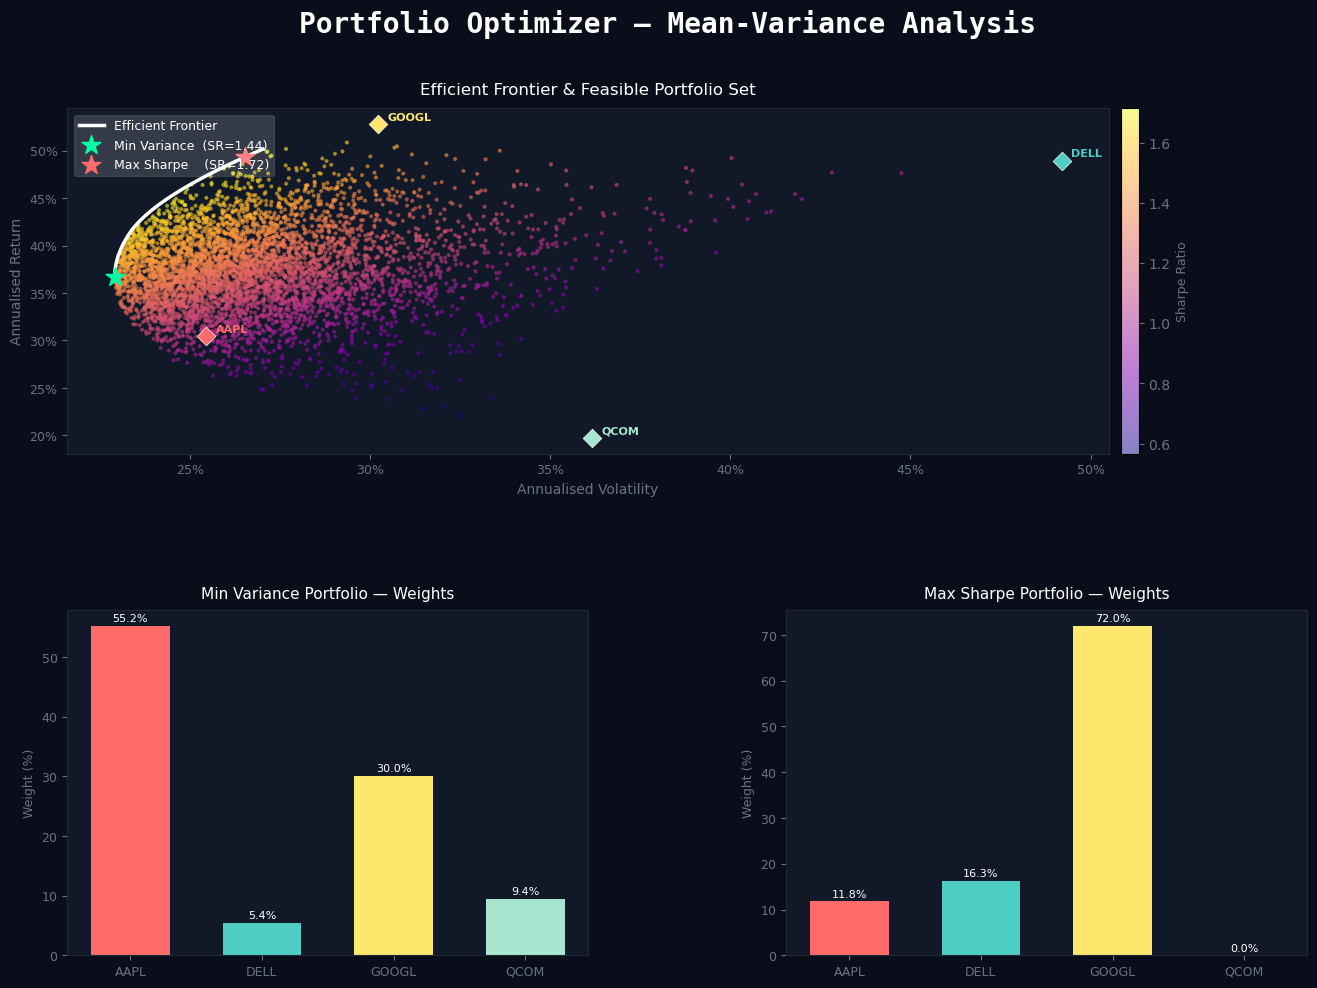

In [15]:
# ── Summary Table ──────────────────────────────────────────────────────────────

def print_summary(mean_returns, cov_matrix, min_w, max_w, tickers):
    min_r, min_v, min_s = portfolio_performance(min_w, mean_returns, cov_matrix)
    max_r, max_v, max_s = portfolio_performance(max_w, mean_returns, cov_matrix)

    print("\n" + "=" * 60)
    print("  INDIVIDUAL ASSET METRICS")
    print("=" * 60)
    rows = []
    for t in tickers:
        r = np.exp(mean_returns[t]) - 1
        v = np.sqrt(cov_matrix.loc[t, t])
        s = (r - RISK_FREE) / v
        rows.append({"Ticker": t,
                     "Ann. Return": f"{r:.1%}",
                     "Ann. Vol":    f"{v:.1%}",
                     "Sharpe":      f"{s:.2f}"})
    print(pd.DataFrame(rows).set_index("Ticker").to_string())

    print("\n" + "=" * 60)
    print("  OPTIMAL PORTFOLIOS")
    print("=" * 60)
    print(f"  {'':25s} {'Return':>10} {'Vol':>10} {'Sharpe':>10}")
    print(f"  {'Min Variance Portfolio':25s} {min_r:>10.1%} {min_v:>10.1%} {min_s:>10.2f}")
    print(f"  {'Max Sharpe Portfolio':25s} {max_r:>10.1%} {max_v:>10.1%} {max_s:>10.2f}")

    print("\n" + "=" * 60)
    print("  PORTFOLIO WEIGHTS")
    print("=" * 60)
    print(f"  {'Ticker':10s} {'Min Variance':>15} {'Max Sharpe':>15}")
    for t, mw, sw in zip(tickers, min_w, max_w):
        print(f"  {t:10s} {mw:>15.1%} {sw:>15.1%}")
    print("=" * 60)


# ── Main ───────────────────────────────────────────────────────────────────────

def main():
    # 1. Load prices
    '''if YFINANCE_AVAILABLE:'''
    prices = fetch_prices(TICKERS, START_DATE, END_DATE)
    '''else:
        print("Using synthetic GBM price data for demo.\n")
        prices = generate_synthetic_prices(TICKERS)'''

    # 2. Compute inputs for optimiser
    log_ret      = compute_log_returns(prices)
    mean_returns = compute_expected_returns(log_ret)
    cov_matrix   = compute_cov_matrix(log_ret)

    # 3. Print correlation matrix (good intuition builder)
    print("CORRELATION MATRIX (how assets move together):")
    corr = log_ret.corr().round(2)
    print(corr.to_string())
    print("  → Values near 1.0 = move together (less diversification benefit)")
    print("  → Values near 0.0 = move independently (more diversification benefit)\n")

    # 4. Find optimal portfolios
    min_w = min_variance_portfolio(mean_returns, cov_matrix)
    max_w = max_sharpe_portfolio(mean_returns, cov_matrix)

    # 5. Print summary
    print_summary(mean_returns, cov_matrix, min_w, max_w, TICKERS)

    # 6. Plot
    print("\nGenerating dashboard...")
    plot_dashboard(prices, mean_returns, cov_matrix)


if __name__ == "__main__":
    main()